# Bahraini Currency Classification with Neural Networks

Three models are built and compared, each with its own prediction and error analysis:

1. **Sequential API** — Flatten + Dense
2. **Functional API** — Flatten + Dense
3. **CNN** — Conv2D + MaxPooling

## Setup

In [1]:
import os

IN_COLAB = os.path.exists('/content')

if IN_COLAB and not os.path.exists('dataset_clean.zip'):
    from google.colab import files
    uploaded = files.upload()
    print(uploaded.keys())
else:
    print("dataset_clean.zip is already here")

dataset_clean.zip is already here


In [2]:
if IN_COLAB:
    !unzip -q -o dataset_clean.zip -d /content/
    base = '/content/dataset_clean'
else:
    base = 'dataset_clean'

print(base)
os.listdir(base)

dataset_clean


['0.5 BHD', '1 BHD', '10 BHD', '20 BHD', '5 BHD']

In [3]:
total = 0
for folder in sorted(os.listdir(base)):
    n = len(os.listdir(os.path.join(base, folder)))
    total += n
    print(folder, n)
print("TOTAL:", total)

0.5 BHD 318
1 BHD 329
10 BHD 298
20 BHD 319
5 BHD 292
TOTAL: 1556


## Loading the Data

Fashion MNIST gave us `x_train` / `y_train` arrays directly. Our images are in
folders, so we load them and turn them into arrays ourselves.

In [4]:
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
import numpy as np

IMG_SIZE = (64, 64)

full = image_dataset_from_directory(
    base,
    image_size=IMG_SIZE,
    batch_size=32,
    shuffle=True,
    seed=123
)

class_names = full.class_names

X = []
y = []
for images, labels in full:
    X.extend(images.numpy())
    y.extend(labels.numpy())

X = np.array(X, dtype='uint8')
y = np.array(y)

X.shape, y.shape

Found 1556 files belonging to 5 classes.


((1556, 64, 64, 3), (1556,))

The folders are read in **alphabetical** order, so `10 BHD` comes before `5 BHD`.
Copy this list into the Streamlit app exactly as printed.

In [5]:
class_names

['0.5 BHD', '1 BHD', '10 BHD', '20 BHD', '5 BHD']

In [6]:
#split to train, val and test

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2,
                                                  random_state=42, stratify=y_train)

x_train.shape, x_val.shape, x_test.shape

((995, 64, 64, 3), (249, 64, 64, 3), (312, 64, 64, 3))

## Looking at the Data

In [7]:
x_train.shape

(995, 64, 64, 3)

In [8]:
x_train[0]

array([[[154, 165, 160],
        [223, 221, 212],
        [173, 183, 178],
        ...,
        [192, 194, 188],
        [225, 229, 220],
        [194, 194, 183]],

       [[198, 203, 194],
        [196, 199, 193],
        [207, 210, 201],
        ...,
        [205, 207, 201],
        [201, 205, 200],
        [213, 214, 206]],

       [[146, 157, 153],
        [221, 226, 221],
        [198, 204, 195],
        ...,
        [199, 201, 194],
        [160, 167, 164],
        [214, 219, 213]],

       ...,

       [[190, 191, 183],
        [193, 188, 177],
        [218, 222, 217],
        ...,
        [188, 189, 183],
        [224, 218, 206],
        [181, 182, 176]],

       [[170, 175, 168],
        [200, 203, 196],
        [198, 200, 202],
        ...,
        [142, 150, 145],
        [213, 211, 204],
        [175, 174, 163]],

       [[168, 172, 169],
        [177, 179, 176],
        [173, 173, 172],
        ...,
        [168, 175, 175],
        [184, 188, 178],
        [185, 177, 167]]

In [9]:
y_train[0]

np.int32(4)

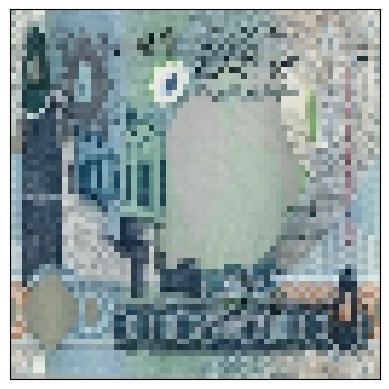

In [10]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.xticks([])
plt.yticks([]);

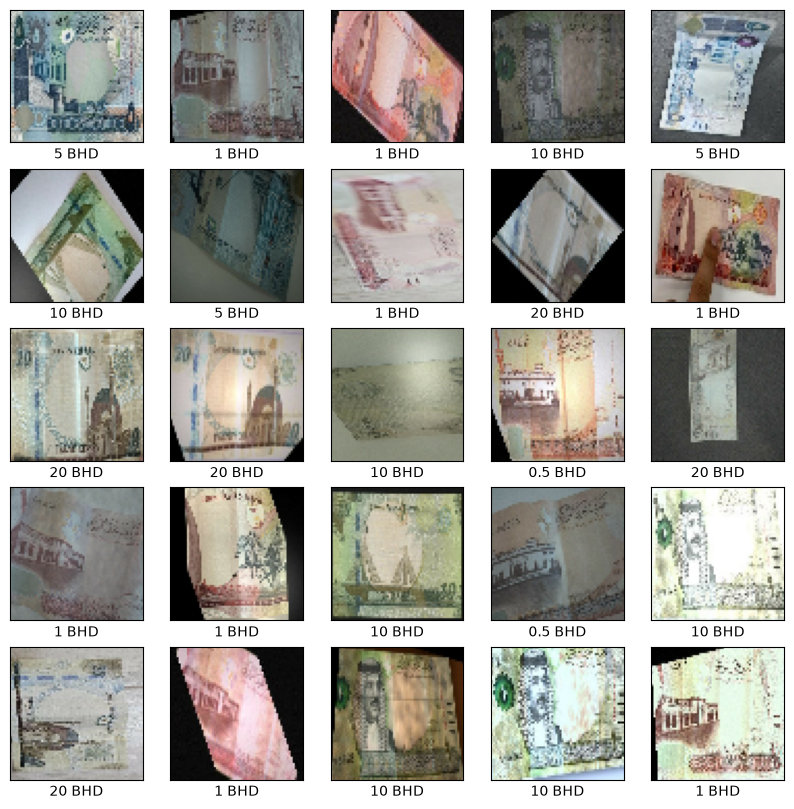

In [11]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [12]:
import pandas as pd
pd.Series([class_names[i] for i in y_train]).value_counts()

1 BHD      210
20 BHD     204
0.5 BHD    203
10 BHD     191
5 BHD      187
Name: count, dtype: int64

## Preprocessing

Same as `x_train/255` with Fashion MNIST.

In [13]:
x_train[0].max()

np.uint8(240)

In [14]:
x_train_scaled = x_train/255
x_val_scaled = x_val/255
x_test_scaled = x_test/255

x_train_scaled[0].max()

np.float64(0.9411764705882353)

### Class Weights

This helps with imbalanced dataset.

In [15]:
from sklearn.utils import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced",
                                     classes=np.unique(y_train), y=y_train)
class_weights

array([0.98029557, 0.94761905, 1.04188482, 0.9754902 , 1.06417112])

In [16]:
# fit() needs a dictionary, not an array
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(0.9802955665024631),
 1: np.float64(0.9476190476190476),
 2: np.float64(1.0418848167539267),
 3: np.float64(0.9754901960784313),
 4: np.float64(1.0641711229946524)}

In [17]:
from tensorflow.keras.utils import set_random_seed
import random

seed = 100

random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# Model 1: Sequential API

- one input, one output

In [19]:
# Seq API
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

#Step2
# The images are colour, so the shape is (64, 64, 3) and not (64, 64)
model_seq = Sequential()
model_seq.add(Input(shape=(64, 64, 3)))
model_seq.add(Flatten())                     # image 3D -> 1D
model_seq.add(Dense(500, activation='relu')) # hidden layer
model_seq.add(Dense(200, activation='relu')) # hidden layer
model_seq.add(Dense(100, activation='relu')) # hidden layer

model_seq.add(Dense(5, activation='softmax')) # output layer -> number of classes

model_seq.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     6,144,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,265,305 (23.90 MB)

 Trainable params: 6,265,305 (23.90 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Step3: Compile
# sparse_categorical_crossentropy

model_seq.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [21]:
# Step4: Fitting (Learning)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_seq = model_seq.fit(x_train_scaled, y_train,
                            validation_data=(x_val_scaled, y_val),
                            epochs=100, callbacks=[es],
                            class_weight=class_weights)

Epoch 1/100


 1/32 ━━━━━━━━━━━━━━━━━━━━ 1:07 2s/step - acc: 0.2500 - loss: 1.6281

 2/32 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - acc: 0.2344 - loss: 3.2737

 3/32 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - acc: 0.1979 - loss: 4.1047

 4/32 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - acc: 0.1953 - loss: 6.5282

...

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - acc: 0.7188 - loss: 0.7571

30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - acc: 0.7125 - loss: 0.7694

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - acc: 0.7157 - loss: 0.7590

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - acc: 0.7166 - loss: 0.7576

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - acc: 0.7166 - loss: 0.7576 - val_acc: 0.5301 - val_loss: 1.2672


## History (Sequential)

In [22]:
history_seq_df = pd.DataFrame(history_seq.history)
history_seq_df.tail()

,acc,loss,val_acc,val_loss
17,0.666332,0.843329,0.485944,1.404326
18,0.682412,0.831005,0.485944,1.299490
19,0.695477,0.810423,0.477912,1.223883
20,0.715578,0.760806,0.502008,1.199080
21,0.716583,0.757556,0.530120,1.267224


<Axes: title={'center': 'Sequential: accuracy'}>

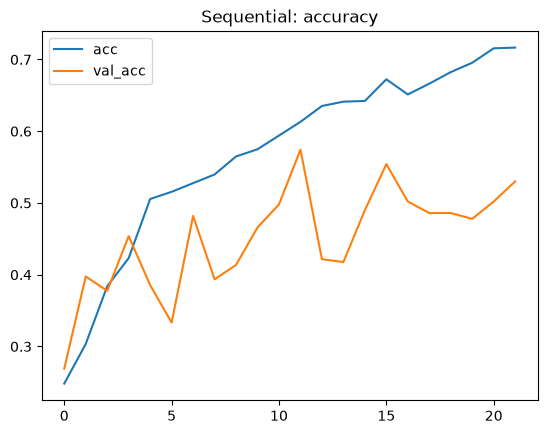

In [23]:
history_seq_df[['acc', 'val_acc']].plot(title="Sequential: accuracy")

<Axes: title={'center': 'Sequential: loss'}>

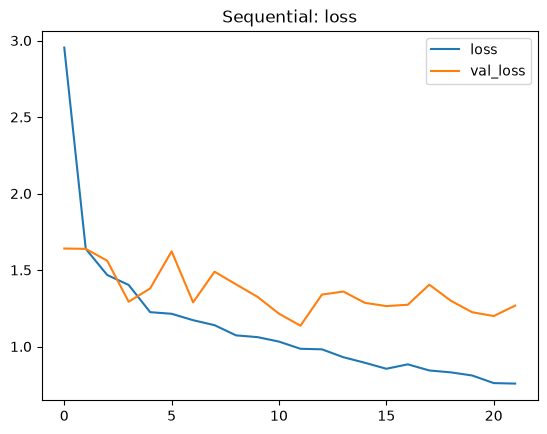

In [24]:
history_seq_df[['loss', 'val_loss']].plot(title="Sequential: loss")

## Prediction (Sequential)

In [25]:
pred = model_seq.predict(x_test_scaled[:1])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


array([[0.02053683, 0.07795091, 0.4944054 , 0.14429249, 0.26281443]],
      dtype=float32)

In [26]:
max(model_seq.predict(x_test_scaled[:1])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


np.float32(0.4944054)

In [27]:
np.argmax(model_seq.predict(x_test_scaled[:1])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


np.int64(2)

In [28]:
class_names[np.argmax(model_seq.predict(x_test_scaled[:1])[0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


'10 BHD'

In [29]:
#step5: Prediction

y_pred_seq = model_seq.predict(x_test_scaled)
y_pred_seq.shape

 1/10 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


(312, 5)

In [30]:
for class_name, prop in zip(class_names, y_pred_seq[0]):
    print(class_name, prop)

0.5 BHD 0.020536866
1 BHD 0.07795056
10 BHD 0.49440667
20 BHD 0.14429247
5 BHD 0.26281342


In [31]:
y_pred_seq_label = y_pred_seq.argmax(axis=1)
y_pred_seq_label

array([2, 2, 2, 2, 2, 0, 3, 0, 1, 2, 2, 1, 0, 2, 3, 2, 1, 0, 2, 4, 2, 0,
       2, 2, 4, 3, 1, 4, 4, 2, 2, 1, 3, 0, 2, 2, 2, 4, 4, 4, 4, 1, 1, 4,
       2, 4, 2, 2, 2, 2, 2, 4, 3, 3, 2, 4, 2, 3, 1, 2, 2, 2, 3, 3, 2, 3,
       2, 1, 1, 2, 4, 3, 2, 0, 2, 2, 2, 2, 2, 2, 2, 4, 4, 0, 0, 2, 1, 2,
       1, 1, 4, 4, 1, 0, 2, 2, 2, 2, 4, 3, 4, 3, 0, 2, 0, 3, 0, 2, 4, 1,
       0, 0, 1, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 0, 2, 0, 2, 1, 1, 3, 0,
       1, 2, 4, 1, 1, 3, 0, 3, 2, 2, 1, 2, 2, 1, 2, 2, 4, 1, 1, 4, 2, 2,
       2, 4, 2, 2, 2, 4, 2, 3, 2, 2, 2, 4, 1, 0, 4, 3, 2, 4, 0, 4, 4, 2,
       4, 2, 1, 2, 4, 0, 2, 4, 4, 2, 2, 2, 4, 2, 0, 2, 2, 4, 2, 3, 0, 0,
       4, 2, 2, 2, 2, 2, 0, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 0, 3, 4, 4,
       2, 0, 0, 4, 2, 2, 1, 4, 4, 2, 1, 1, 2, 3, 0, 2, 1, 4, 0, 3, 1, 2,
       0, 2, 0, 2, 1, 3, 4, 1, 0, 4, 0, 1, 1, 2, 2, 2, 1, 2, 2, 4, 1, 2,
       1, 4, 2, 3, 2, 1, 4, 4, 4, 4, 1, 1, 2, 0, 2, 0, 0, 2, 2, 4, 4, 4,
       4, 2, 2, 4, 2, 4, 2, 2, 4, 0, 2, 2, 2, 2, 4,

## Eval (Sequential)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_score(y_test, y_pred_seq_label)

0.5512820512820513

In [33]:
model_seq.evaluate(x_test_scaled, y_test)

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.5000 - loss: 1.1460

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.5625 - loss: 1.1071 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.5513 - loss: 1.1152


[1.1152241230010986, 0.5512820482254028]

## Error Analysis (Sequential)

In [34]:
print(classification_report(y_test, y_pred_seq_label,
                            labels=range(len(class_names)),
                            target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

     0.5 BHD       0.77      0.47      0.58        64
       1 BHD       0.60      0.45      0.52        66
      10 BHD       0.38      0.85      0.53        60
      20 BHD       0.68      0.30      0.41        64
       5 BHD       0.69      0.72      0.71        58

    accuracy                           0.55       312
   macro avg       0.62      0.56      0.55       312
weighted avg       0.63      0.55      0.55       312



In [35]:
conf_seq = confusion_matrix(y_test, y_pred_seq_label, labels=range(len(class_names)))
conf_seq

array([[30, 13, 20,  0,  1],
       [ 4, 30, 22,  2,  8],
       [ 2,  1, 51,  2,  4],
       [ 3,  5, 31, 19,  6],
       [ 0,  1, 10,  5, 42]])

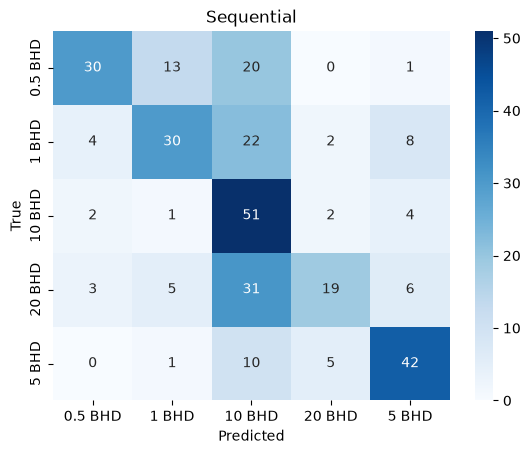

In [36]:
import seaborn as sns

sns.heatmap(conf_seq, annot=True, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Sequential")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

number wrong: 140


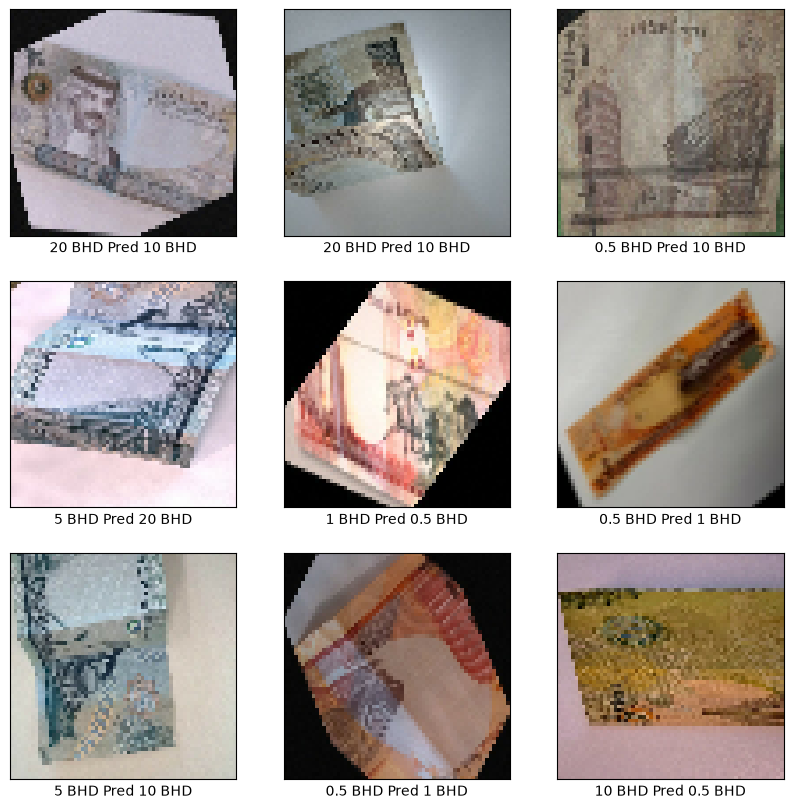

In [37]:
idx = np.where(y_test != y_pred_seq_label)[0]   # all the img the model got wrong
print("number wrong:", len(idx))

plt.figure(figsize=(10, 10))
for i in range(min(9, len(idx))):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[idx[i]])
    plt.xlabel(f"{class_names[y_test[idx[i]]]} Pred {class_names[y_pred_seq_label[idx[i]]]}")
plt.show()

# Model 2: Functional API

Same architecture as the Sequential model, written a different way.

In [38]:
# STep1: Import
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input

# Step 2
inputs = Input(shape=(64, 64, 3))

x = Flatten()(inputs)
x = Dense(500, activation='relu')(x)
x = Dense(200, activation='relu')(x)
x = Dense(100, activation='relu')(x)

outputs = Dense(5, activation='softmax')(x)

model_func = Model(inputs=inputs, outputs=outputs)

model_func.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │     6,144,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,265,305 (23.90 MB)

 Trainable params: 6,265,305 (23.90 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.utils import plot_model
plot_model(model_func, show_shapes=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [40]:
# STep3: Compile
model_func.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [41]:
#STep4: Fitting
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_func = model_func.fit(x_train_scaled, y_train,
                              validation_data=(x_val_scaled, y_val),
                              epochs=100, callbacks=[es],
                              class_weight=class_weights)

Epoch 1/100


 1/32 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - acc: 0.3125 - loss: 1.6135

 2/32 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - acc: 0.2188 - loss: 5.9905

 3/32 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - acc: 0.2396 - loss: 5.7935

 4/32 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - acc: 0.2344 - loss: 7.1372 

...

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - acc: 0.6552 - loss: 0.8996

30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - acc: 0.6562 - loss: 0.9025

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - acc: 0.6573 - loss: 0.8980

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - acc: 0.6583 - loss: 0.8959

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - acc: 0.6583 - loss: 0.8959 - val_acc: 0.4659 - val_loss: 1.3336


## History (Functional)

In [42]:
history_func_df = pd.DataFrame(history_func.history)
history_func_df.tail()

,acc,loss,val_acc,val_loss
10,0.639196,0.950641,0.502008,1.266771
11,0.638191,0.934880,0.465863,1.323977
12,0.662312,0.892977,0.457831,1.326203
13,0.654271,0.909575,0.473896,1.300579
14,0.658291,0.895887,0.465863,1.333588


<Axes: title={'center': 'Functional: accuracy'}>

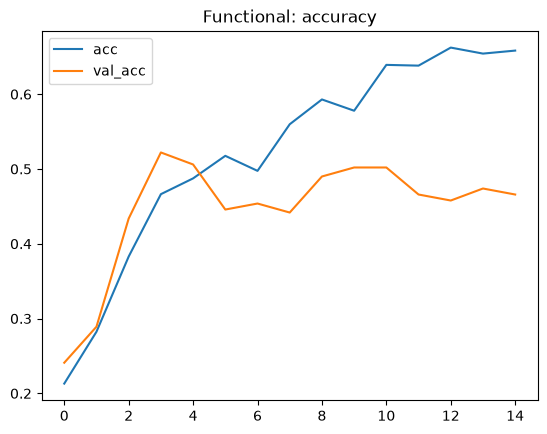

In [43]:
history_func_df[['acc', 'val_acc']].plot(title="Functional: accuracy")

<Axes: title={'center': 'Functional: loss'}>

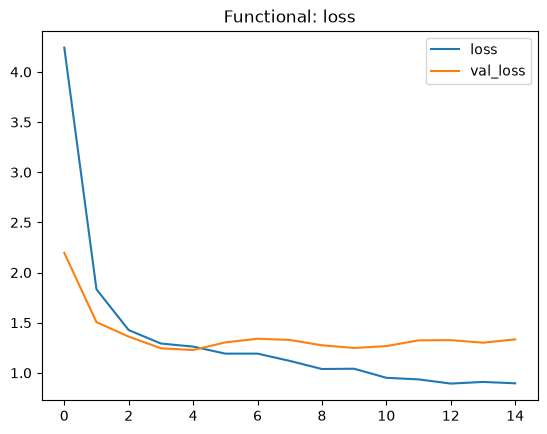

In [44]:
history_func_df[['loss', 'val_loss']].plot(title="Functional: loss")

## Prediction (Functional)

In [45]:
pred = model_func.predict(x_test_scaled[:1])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


array([[0.05030359, 0.20613205, 0.18187766, 0.25246507, 0.30922163]],
      dtype=float32)

In [46]:
class_names[np.argmax(model_func.predict(x_test_scaled[:1])[0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


'5 BHD'

In [47]:
y_pred_func = model_func.predict(x_test_scaled)
y_pred_func_label = y_pred_func.argmax(axis=1)
y_pred_func_label

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([4, 2, 1, 4, 1, 0, 4, 1, 1, 2, 2, 1, 0, 1, 3, 1, 1, 1, 1, 4, 1, 1,
       1, 1, 4, 1, 1, 4, 4, 2, 1, 1, 3, 0, 1, 1, 1, 4, 4, 4, 4, 1, 1, 4,
       1, 4, 1, 1, 1, 1, 1, 4, 1, 3, 3, 4, 3, 3, 1, 3, 1, 4, 3, 3, 2, 4,
       2, 1, 1, 1, 4, 3, 2, 0, 1, 3, 1, 1, 1, 1, 1, 4, 4, 1, 0, 4, 1, 2,
       1, 1, 4, 4, 1, 1, 2, 2, 1, 1, 1, 3, 4, 3, 0, 4, 1, 4, 0, 2, 4, 1,
       0, 0, 1, 1, 3, 1, 1, 1, 1, 1, 1, 2, 1, 3, 1, 1, 0, 2, 1, 1, 4, 0,
       1, 1, 4, 1, 1, 4, 1, 4, 1, 3, 1, 2, 1, 1, 1, 1, 4, 1, 1, 4, 1, 1,
       2, 4, 1, 1, 2, 4, 1, 3, 2, 1, 1, 4, 1, 0, 4, 1, 4, 4, 0, 4, 4, 1,
       1, 1, 1, 4, 1, 0, 1, 4, 4, 2, 1, 1, 4, 2, 0, 2, 1, 4, 1, 3, 0, 0,
       4, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 4, 2, 4, 1, 2, 0, 3, 4, 4,
       2, 1, 1, 4, 4, 2, 1, 4, 4, 2, 1, 1, 2, 3, 0, 1, 1, 4, 0, 3, 1, 2,
       1, 2, 0, 2, 1, 1, 4, 1, 0, 4, 0, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1,
       1, 4, 1, 1, 1, 1, 4, 4, 4, 4, 1, 1, 2, 0, 1, 0, 0, 2, 1, 4, 1, 4,
       4, 1, 1, 4, 1, 4, 1, 1, 4, 0, 2, 1, 1, 1, 4,

## Eval (Functional)

In [48]:
accuracy_score(y_test, y_pred_func_label)

0.4935897435897436

In [49]:
model_func.evaluate(x_test_scaled, y_test)

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.3438 - loss: 1.2728

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.5000 - loss: 1.1967 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.4936 - loss: 1.1969


[1.1968510150909424, 0.49358972907066345]

## Error Analysis (Functional)

In [50]:
print(classification_report(y_test, y_pred_func_label,
                            labels=range(len(class_names)),
                            target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

     0.5 BHD       0.81      0.34      0.48        64
       1 BHD       0.36      0.82      0.50        66
      10 BHD       0.51      0.35      0.42        60
      20 BHD       0.55      0.19      0.28        64
       5 BHD       0.62      0.78      0.69        58

    accuracy                           0.49       312
   macro avg       0.57      0.50      0.47       312
weighted avg       0.57      0.49      0.47       312



In [51]:
conf_func = confusion_matrix(y_test, y_pred_func_label, labels=range(len(class_names)))
conf_func

array([[22, 41,  0,  0,  1],
       [ 2, 54,  2,  1,  7],
       [ 2, 22, 21,  6,  9],
       [ 1, 29, 12, 12, 10],
       [ 0,  4,  6,  3, 45]])

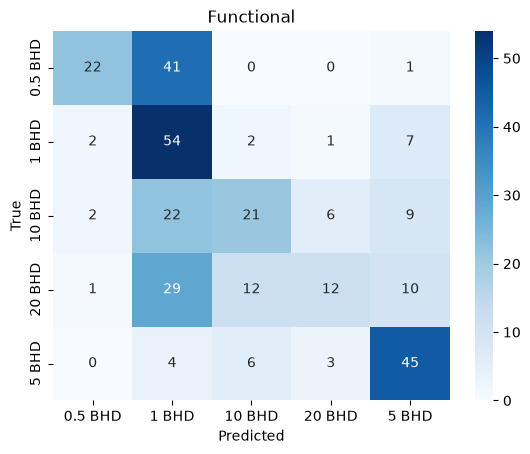

In [52]:
sns.heatmap(conf_func, annot=True, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Functional")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

number wrong: 158


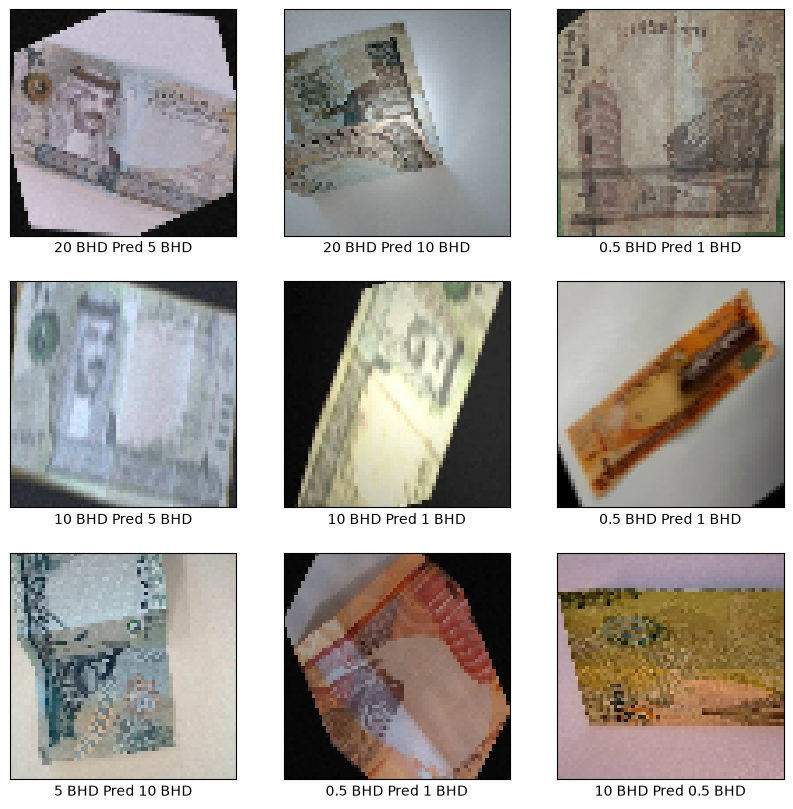

In [53]:
idx = np.where(y_test != y_pred_func_label)[0]
print("number wrong:", len(idx))

plt.figure(figsize=(10, 10))
for i in range(min(9, len(idx))):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[idx[i]])
    plt.xlabel(f"{class_names[y_test[idx[i]]]} Pred {class_names[y_pred_func_label[idx[i]]]}")
plt.show()

# Model 3: CNN

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation

model_cnn = Sequential()
model_cnn.add(Input(shape=(64, 64, 3)))

model_cnn.add(RandomFlip("horizontal"))
model_cnn.add(RandomRotation(0.15))
model_cnn.add(RandomZoom(0.4))
model_cnn.add(RandomTranslation(0.2, 0.2))

model_cnn.add(Conv2D(32, 3, activation='relu'))
model_cnn.add(MaxPooling2D(2))
model_cnn.add(Conv2D(64, 3, activation='relu'))
model_cnn.add(MaxPooling2D(2))
model_cnn.add(Conv2D(128, 3, activation='relu'))
model_cnn.add(MaxPooling2D(2))

model_cnn.add(Flatten())
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(128, activation='relu'))

model_cnn.add(Dense(5, activation='softmax'))

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 64, 64, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,845 (2.61 MB)

 Trainable params: 683,845 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [56]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = model_cnn.fit(x_train_scaled, y_train,
                            validation_data=(x_val_scaled, y_val),
                            epochs=100, callbacks=[es],
                            class_weight=class_weights)

Epoch 1/100


 1/32 ━━━━━━━━━━━━━━━━━━━━ 2:03 4s/step - acc: 0.1875 - loss: 1.6286

 2/32 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - acc: 0.1719 - loss: 1.6227

 3/32 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - acc: 0.1771 - loss: 1.6214

 4/32 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - acc: 0.1797 - loss: 1.6199

...

28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.7824 - loss: 0.5522

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.7780 - loss: 0.5665

30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.7812 - loss: 0.5624

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.7823 - loss: 0.5597

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - acc: 0.7809 - loss: 0.5612 - val_acc: 0.7671 - val_loss: 0.6062


## History (CNN)

In [57]:
history_cnn_df = pd.DataFrame(history_cnn.history)
history_cnn_df.tail()

,acc,loss,val_acc,val_loss
52,0.778894,0.566908,0.742972,0.632088
53,0.760804,0.617738,0.658635,0.970136
54,0.761809,0.585023,0.795181,0.563220
55,0.765829,0.599070,0.755020,0.697706
56,0.780905,0.561221,0.767068,0.606229


<Axes: title={'center': 'CNN: accuracy'}>

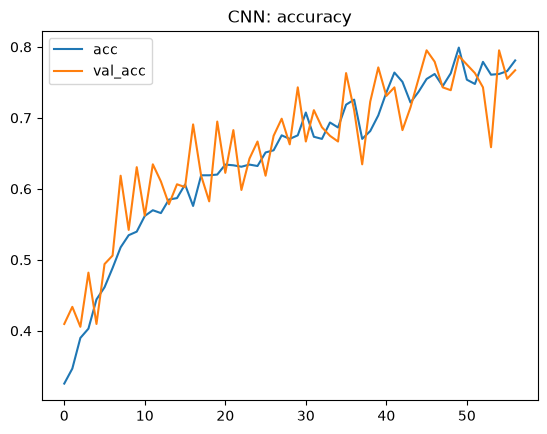

In [58]:
history_cnn_df[['acc', 'val_acc']].plot(title="CNN: accuracy")

<Axes: title={'center': 'CNN: loss'}>

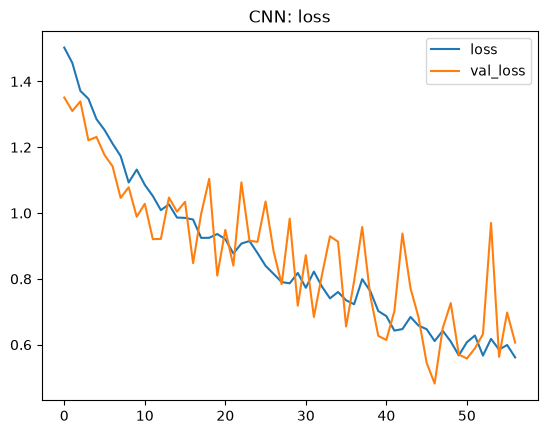

In [59]:
history_cnn_df[['loss', 'val_loss']].plot(title="CNN: loss")

## Prediction (CNN)

In [60]:
pred = model_cnn.predict(x_test_scaled[:1])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


array([[0.03556003, 0.10758106, 0.05820251, 0.75749516, 0.04116122]],
      dtype=float32)

In [61]:
class_names[np.argmax(model_cnn.predict(x_test_scaled[:1])[0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


'20 BHD'

In [62]:
y_pred_cnn = model_cnn.predict(x_test_scaled)
y_pred_cnn_label = y_pred_cnn.argmax(axis=1)
y_pred_cnn_label

 1/10 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step

 4/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 

 7/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([3, 3, 0, 3, 2, 0, 4, 1, 0, 2, 4, 0, 2, 2, 3, 3, 1, 0, 3, 4, 1, 0,
       2, 0, 3, 3, 1, 4, 4, 2, 3, 1, 3, 0, 1, 3, 1, 4, 4, 4, 4, 1, 0, 4,
       2, 4, 2, 2, 1, 0, 0, 4, 3, 3, 2, 4, 2, 3, 0, 3, 3, 2, 4, 3, 3, 1,
       3, 1, 1, 3, 4, 4, 2, 0, 3, 3, 2, 0, 1, 0, 3, 4, 4, 0, 0, 3, 4, 1,
       1, 3, 4, 4, 1, 0, 2, 2, 3, 3, 1, 3, 4, 3, 0, 4, 0, 4, 2, 1, 4, 3,
       0, 0, 2, 3, 3, 3, 2, 3, 2, 1, 0, 2, 3, 3, 0, 4, 0, 4, 1, 1, 4, 0,
       1, 3, 3, 1, 1, 4, 0, 4, 1, 3, 3, 2, 1, 1, 2, 3, 1, 1, 1, 4, 0, 2,
       2, 2, 1, 0, 3, 4, 1, 3, 2, 3, 1, 4, 1, 0, 3, 3, 4, 4, 3, 4, 4, 3,
       3, 1, 0, 3, 1, 0, 1, 4, 4, 3, 0, 2, 4, 4, 0, 2, 1, 4, 1, 3, 0, 0,
       3, 2, 2, 2, 2, 3, 3, 0, 1, 3, 2, 3, 1, 3, 3, 4, 3, 2, 0, 3, 3, 4,
       4, 0, 0, 4, 2, 2, 1, 3, 3, 3, 3, 3, 4, 2, 0, 1, 0, 1, 0, 3, 1, 2,
       0, 2, 0, 2, 0, 3, 4, 1, 0, 4, 0, 1, 0, 2, 3, 2, 0, 3, 3, 4, 1, 2,
       1, 4, 1, 3, 1, 1, 4, 4, 4, 4, 3, 1, 3, 0, 0, 1, 0, 2, 3, 1, 3, 4,
       3, 2, 3, 4, 2, 2, 3, 0, 1, 0, 3, 3, 1, 3, 4,

In [63]:
for class_name, prop in zip(class_names, y_pred_cnn[0]):
    print(class_name, prop)

0.5 BHD 0.035560038
1 BHD 0.107581116
10 BHD 0.05820251
20 BHD 0.75749516
5 BHD 0.041161224


## Eval (CNN)

In [64]:
accuracy_score(y_test, y_pred_cnn_label)

0.8397435897435898

In [65]:
model_cnn.evaluate(x_test_scaled, y_test)

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.8438 - loss: 0.4574

 3/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.8229 - loss: 0.4755

 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.8333 - loss: 0.4373

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.8438 - loss: 0.4218

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.8397 - loss: 0.4341


[0.43410003185272217, 0.8397436141967773]

## Error Analysis (CNN)

In [66]:
print(classification_report(y_test, y_pred_cnn_label,
                            labels=range(len(class_names)),
                            target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

     0.5 BHD       0.95      0.83      0.88        64
       1 BHD       0.95      0.86      0.90        66
      10 BHD       0.92      0.75      0.83        60
      20 BHD       0.63      0.86      0.73        64
       5 BHD       0.87      0.90      0.88        58

    accuracy                           0.84       312
   macro avg       0.86      0.84      0.84       312
weighted avg       0.86      0.84      0.84       312


In [67]:
conf_cnn = confusion_matrix(y_test, y_pred_cnn_label, labels=range(len(class_names)))
conf_cnn

array([[53,  3,  0,  8,  0],
       [ 2, 57,  0,  7,  0],
       [ 0,  0, 45, 13,  2],
       [ 1,  0,  2, 55,  6],
       [ 0,  0,  2,  4, 52]])

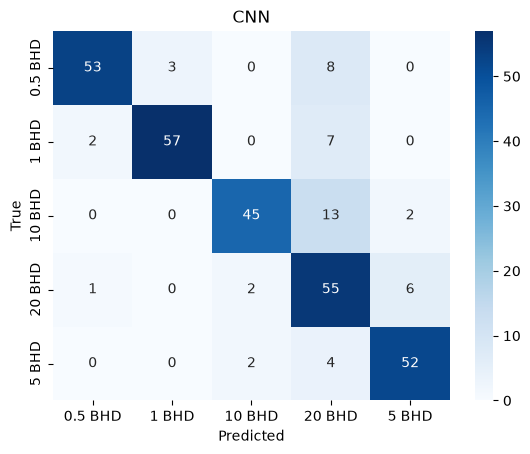

In [68]:
sns.heatmap(conf_cnn, annot=True, cmap='Blues', fmt='g',
            xticklabels=class_names, yticklabels=class_names)
plt.title("CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()

number wrong: 50


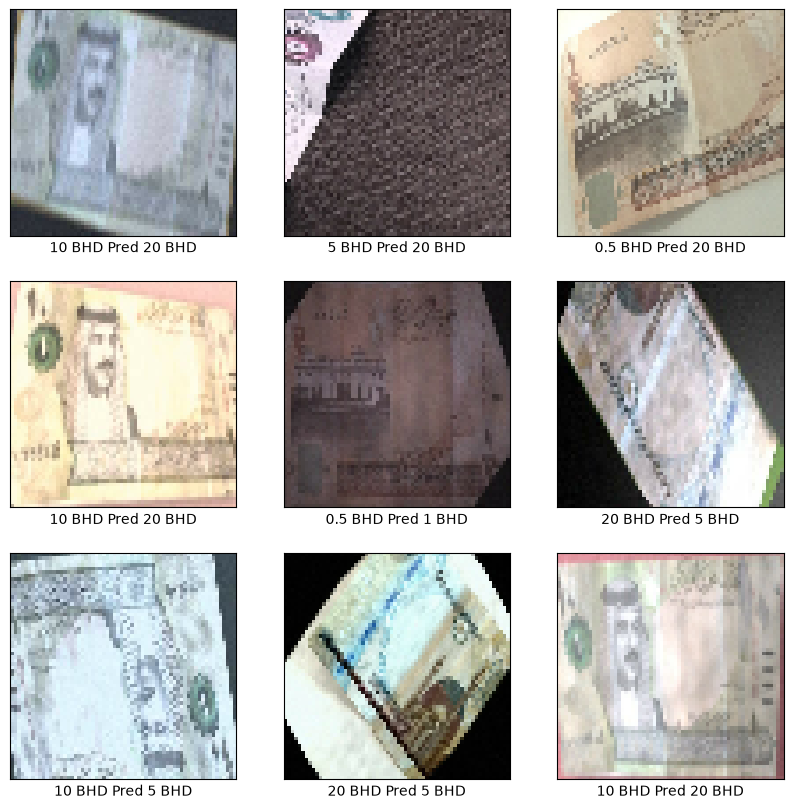

In [69]:
idx = np.where(y_test != y_pred_cnn_label)[0]
print("number wrong:", len(idx))

plt.figure(figsize=(10, 10))
for i in range(min(9, len(idx))):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[idx[i]])
    plt.xlabel(f"{class_names[y_test[idx[i]]]} Pred {class_names[y_pred_cnn_label[idx[i]]]}")
plt.show()

# Comparing the Three Models

In [70]:
results = pd.DataFrame({
    'model': ['Sequential', 'Functional', 'CNN'],
    'parameters': [model_seq.count_params(), model_func.count_params(), model_cnn.count_params()],
    'test accuracy': [accuracy_score(y_test, y_pred_seq_label),
                      accuracy_score(y_test, y_pred_func_label),
                      accuracy_score(y_test, y_pred_cnn_label)]
})
results

,model,parameters,test accuracy
0,Sequential,6265305,0.551282
1,Functional,6265305,0.493590
2,CNN,683845,0.839744


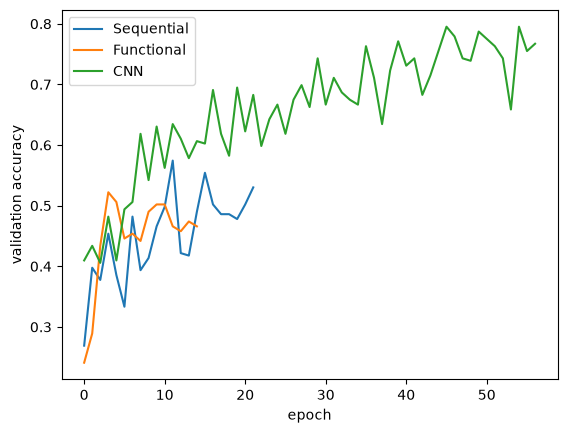

In [71]:
plt.plot(history_seq_df['val_acc'], label='Sequential')
plt.plot(history_func_df['val_acc'], label='Functional')
plt.plot(history_cnn_df['val_acc'], label='CNN')
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.show()

## Save the Best Model for the Streamlit App

In [72]:
model_cnn.save("currency_model.keras")
print("saved currency_model.keras")
print("copy this into the app:")
print(class_names)

saved currency_model.keras
copy this into the app:
['0.5 BHD', '1 BHD', '10 BHD', '20 BHD', '5 BHD']


In [73]:
if IN_COLAB:
    from google.colab import files
    files.download("currency_model.keras")